# Klassifikation der Fahrzeugpreiskategorie

## Ziel des Notebooks

In diesem Notebook wird eine Klassifikation durchgeführt.

Das Ziel ist nicht die direkte Vorhersage des Fahrzeugpreises als numerischer Wert,
sondern die Einteilung der Fahrzeuge in drei Preiskategorien:

- Günstig
- Mittel
- Teuer

Damit ergänzt dieses Notebook die Regressionsmodelle des Projekts und erfüllt den optionalen Klassifikationsteil.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("data/processed/cleaned_data.csv")

In [ ]:
df.head()

,Datum,Marke,Modell,Preis_Euro,Verkaufszahl,Kraftstoff,Getriebe,Hubraum_L,Bundesland,Kundenzufriedenheit,Jahr,Monat,Wochentag
0,2024-01-01,Mercedes-Benz,C-Klasse,66835,2,Elektro,Automatik,0.0,Berlin,4.7,2024,1,Monday
1,2024-01-01,Mercedes-Benz,E-Klasse,93803,2,Benzin,Manuell,1.2,Nrw,3.2,2024,1,Monday
2,2024-01-07,Volkswagen,Passat,45929,6,Hybrid,Manuell,2.0,Baden-Württemberg,3.2,2024,1,Sunday
3,2024-01-07,Mercedes-Benz,C-Klasse,76943,3,Diesel,Automatik,4.0,Berlin,3.4,2024,1,Sunday
4,2024-01-08,Bmw,5Er,107912,1,Elektro,Automatik,0.0,Berlin,3.2,2024,1,Monday


In [ ]:
print(df.columns.tolist())

['Datum', 'Marke', 'Modell', 'Preis_Euro', 'Verkaufszahl', 'Kraftstoff', 'Getriebe', 'Hubraum_L', 'Bundesland', 'Kundenzufriedenheit', 'Jahr', 'Monat', 'Wochentag']


In [ ]:
df["Preis_Kategorie"] = pd.qcut(
    df["Preis_Euro"],
    q=3,
    labels=["Günstig", "Mittel", "Teuer"]
)

df[["Preis_Euro", "Preis_Kategorie"]].head(10)

,Preis_Euro,Preis_Kategorie
0,66835,Mittel
1,93803,Teuer
2,45929,Mittel
3,76943,Teuer
4,107912,Teuer
5,45975,Mittel
6,62180,Mittel
7,33246,Günstig
8,42968,Günstig
9,50518,Mittel


In [ ]:
df["Preis_Kategorie"].value_counts()

Preis_Kategorie
Günstig    400
Mittel     400
Teuer      400
Name: count, dtype: int64

## Erstellung der Zielvariable

Da der ursprüngliche Fahrzeugpreis eine numerische Variable ist,
wird er für die Klassifikation in drei Kategorien eingeteilt:

- Günstig
- Mittel
- Teuer

Die Einteilung erfolgt mit `qcut`, sodass die Klassen möglichst gleich groß sind.
Dadurch entsteht ein ausgewogenes Klassifikationsproblem.

In [ ]:
features = [
    "Verkaufszahl",
    "Hubraum_L",
    "Kundenzufriedenheit",
    "Jahr",
    "Monat",
    "Wochentag",
    "Marke",
    "Modell",
    "Kraftstoff",
    "Getriebe",
    "Bundesland"
]

X = df[features]
y = df["Preis_Kategorie"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1200, 11)
y shape: (1200,)


In [ ]:
numeric_features = [
    "Verkaufszahl",
    "Hubraum_L",
    "Kundenzufriedenheit",
    "Jahr",
    "Monat"
]

categorical_features = [
    "Marke",
    "Modell",
    "Kraftstoff",
    "Getriebe",
    "Bundesland",
    "Wochentag"
]

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Verkaufszahl', 'Hubraum_L', 'Kundenzufriedenheit', 'Jahr', 'Monat']

Categorical Features:
['Marke', 'Modell', 'Kraftstoff', 'Getriebe', 'Bundesland', 'Wochentag']


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (960, 11)
X_test: (240, 11)
y_train: (960,)
y_test: (240,)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

log_reg_model.fit(X_train, y_train)

log_reg_pred = log_reg_model.predict(X_test)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, log_reg_pred)

print("Accuracy:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, log_reg_pred))

Accuracy: 0.6375

Classification Report:
              precision    recall  f1-score   support

     Günstig       0.83      0.86      0.85        80
      Mittel       0.45      0.29      0.35        80
       Teuer       0.58      0.76      0.66        80

    accuracy                           0.64       240
   macro avg       0.62      0.64      0.62       240
weighted avg       0.62      0.64      0.62       240



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest training completed.")

Random Forest training completed.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.6583

Classification Report:
              precision    recall  f1-score   support

     Günstig       0.81      0.91      0.86        80
      Mittel       0.50      0.16      0.25        80
       Teuer       0.58      0.90      0.71        80

    accuracy                           0.66       240
   macro avg       0.63      0.66      0.60       240
weighted avg       0.63      0.66      0.60       240



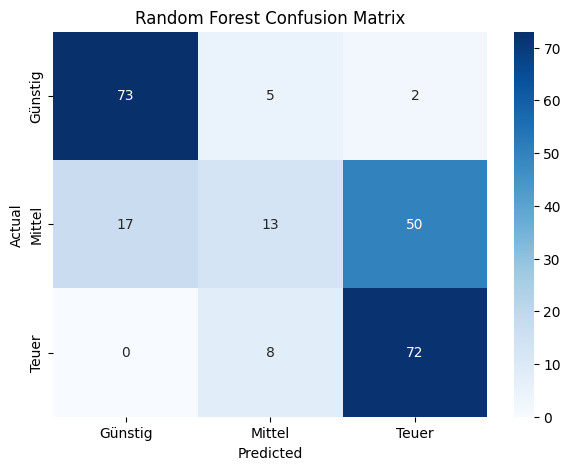

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Günstig","Mittel","Teuer"],
    yticklabels=["Günstig","Mittel","Teuer"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
# Random-Forest-Modell aus der Pipeline extrahieren
rf_classifier = rf_model.named_steps["classifier"]

# Feature-Namen nach One-Hot-Encoding extrahieren
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Feature Importance berechnen
importance_df = pd.DataFrame({
    "Merkmal": feature_names,
    "Wichtigkeit": rf_classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Wichtigkeit",
    ascending=False
)

importance_df.head(15)

,Merkmal,Wichtigkeit
8,cat__Marke_Opel,0.175461
9,cat__Marke_Volkswagen,0.089893
7,cat__Marke_Mercedes-Benz,0.053964
2,num__Kundenzufriedenheit,0.051765
4,num__Monat,0.048025
0,num__Verkaufszahl,0.044835
6,cat__Marke_Bmw,0.043308
16,cat__Modell_Corsa,0.038958
25,cat__Modell_Mokka,0.032278
1,num__Hubraum_L,0.031771


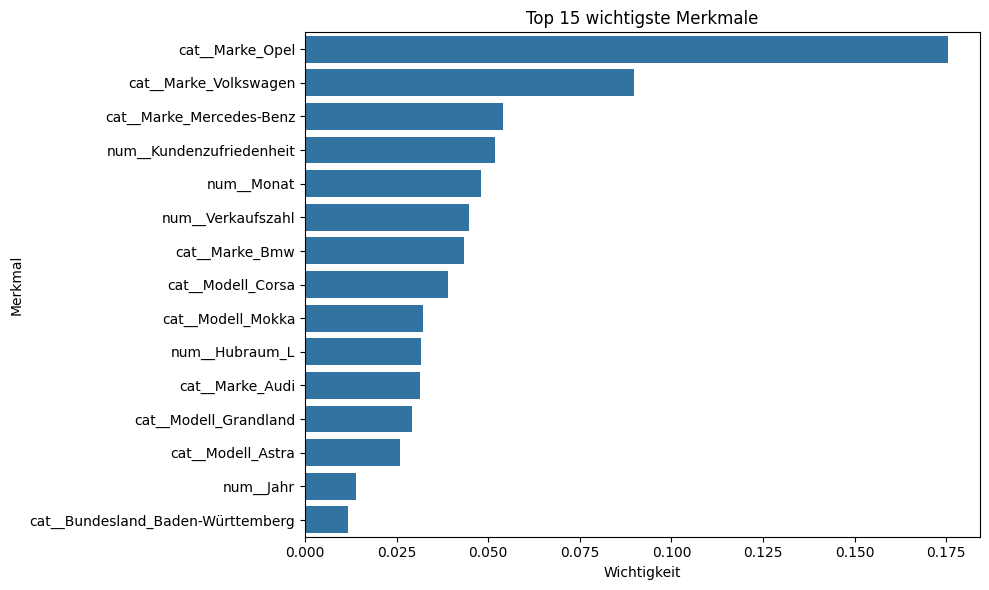

In [ ]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Wichtigkeit",
    y="Merkmal"
)

plt.title("Top 15 wichtigste Merkmale")
plt.xlabel("Wichtigkeit")
plt.ylabel("Merkmal")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
vergleich_df = pd.DataFrame({
    "Modell": [
        "Logistische Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, log_reg_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Macro F1-Score": [
        f1_score(y_test, log_reg_pred, average="macro"),
        f1_score(y_test, rf_pred, average="macro")
    ],
    "Weighted F1-Score": [
        f1_score(y_test, log_reg_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted")
    ]
})

vergleich_df

,Modell,Accuracy,Macro F1-Score,Weighted F1-Score
0,Logistische Regression,0.637500,0.617895,0.617895
1,Random Forest,0.658333,0.603330,0.603330


# Interpretation der Ergebnisse

Im Rahmen dieser Analyse wurden zwei Klassifikationsverfahren verglichen:

- Logistische Regression
- Random Forest

Der Random-Forest-Klassifikator erreichte die höchste Accuracy von 65,83 %.
Die logistische Regression erzielte dagegen einen leicht höheren Macro-F1-Score und zeigte eine ausgewogenere Leistung über alle Klassen hinweg.

Die Analyse der Feature Importance zeigt, dass insbesondere die Fahrzeugmarke einen starken Einfluss auf die Preisgruppe hat.
Darüber hinaus tragen Kundenzufriedenheit, Verkaufszahlen und Hubraum ebenfalls zur Klassifikation bei.

Die Ergebnisse zeigen, dass die Preisgruppe eines Fahrzeugs anhand der verfügbaren Merkmale grundsätzlich vorhergesagt werden kann.
Die Vorhersagegenauigkeit wird jedoch durch die begrenzte Anzahl verfügbarer Einflussvariablen eingeschränkt.

Insgesamt ergänzt diese Klassifikationsanalyse die Regressionsmodelle des Projekts und liefert zusätzliche Erkenntnisse zur Struktur der Fahrzeugpreise.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nDurchschnittliche Accuracy:")
print(cv_scores.mean())

print("\nStandardabweichung:")
print(cv_scores.std())

Cross Validation Scores:
[0.63333333 0.62083333 0.56666667 0.62916667 0.64166667]

Durchschnittliche Accuracy:
0.6183333333333334

Standardabweichung:
0.026692695630078287


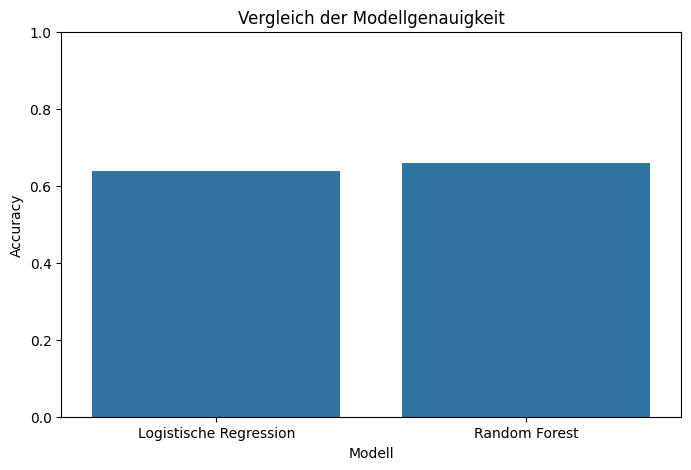

In [ ]:
vergleich_plot = vergleich_df.copy()

plt.figure(figsize=(8,5))

sns.barplot(
    data=vergleich_plot,
    x="Modell",
    y="Accuracy"
)

plt.title("Vergleich der Modellgenauigkeit")
plt.ylabel("Accuracy")
plt.xlabel("Modell")

plt.ylim(0, 1)

plt.show()